In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import csv file and Data Cleaning & Preprocessing 

df=pd.read_csv('Ice_Cream.csv')

print(df.head())

print(df.tail())

print(df.shape)

print(df.describe())

print(df.columns)

print(df.dtypes)

print(df.info())

print(df.isnull().sum())

print(df.duplicated().sum())

print(df.nunique())

   Temperature  Sales
0         24.6    535
1         26.1    626
2         27.8    661
3         20.6    488
4         11.6    317
     Temperature  Sales
495         22.3    525
496         32.9    756
497         12.6    307
498         22.4    567
499         29.0    656
(500, 2)
       Temperature        Sales
count   500.000000   500.000000
mean     22.281600   522.058000
std       8.097597   175.410399
min       0.000000    10.000000
25%      17.175000   406.000000
50%      22.400000   530.000000
75%      27.800000   643.000000
max      45.000000  1000.000000
Index(['Temperature', 'Sales'], dtype='str')
Temperature    float64
Sales            int64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Sales        500 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 7.9 KB
None
Temper

In [4]:
# Remove Duplicates Values

df = df.drop_duplicates()

print(df.duplicated().sum())

0


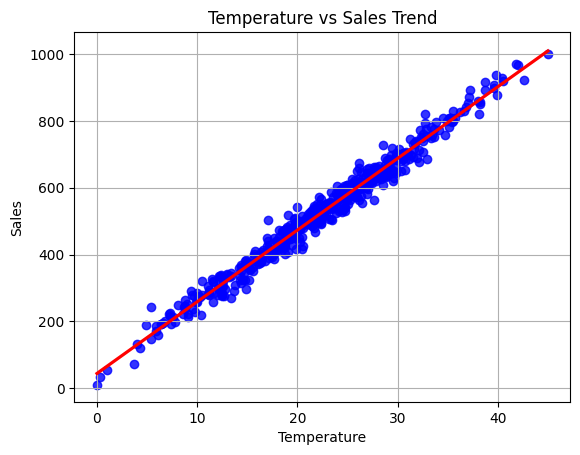

In [5]:
# Tempreature & Sales Trend

sns.regplot(x='Temperature',y='Sales',data=df,scatter_kws={'color':'blue'},line_kws={'color':'red'})
plt.title('Temperature vs Sales Trend')
plt.title('Temperature vs Sales Trend')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

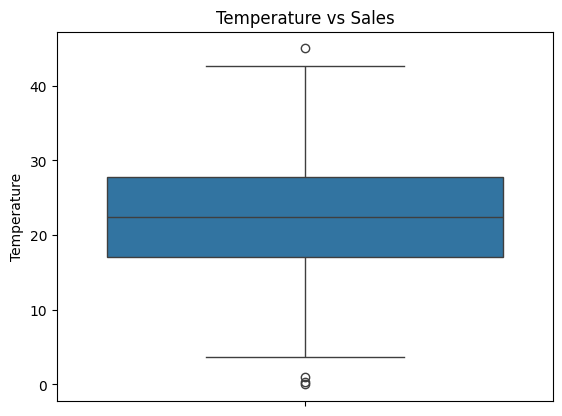

In [6]:
# Outliers in Temperature column

sns.boxplot(df['Temperature'])
plt.xlabel('')
plt.ylabel('Temperature')
plt.title('Temperature vs Sales')
plt.show()

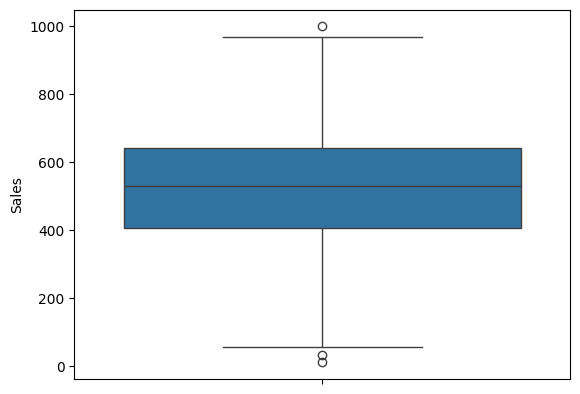

In [7]:
# Outliers in Sales Column

sns.boxplot(df['Sales'])
plt.xlabel('')
plt.ylabel('Sales')
plt.show()

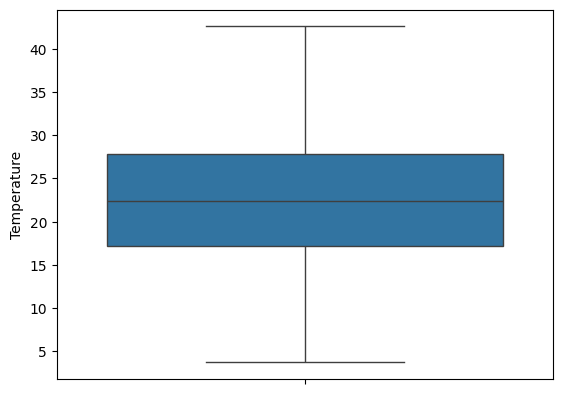

In [8]:
# Remove Outliers from Temperature field

Q1 = df['Temperature'].quantile(0.25)
Q3 = df['Temperature'].quantile(0.75)

IQR = Q3 - Q1

# Find Bouandary

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Set Boundary

df = df[(df['Temperature'] >= lower_bound) & (df['Temperature'] <= upper_bound)]

sns.boxplot(df['Temperature'])
plt.ylabel('Temperature')
plt.show()

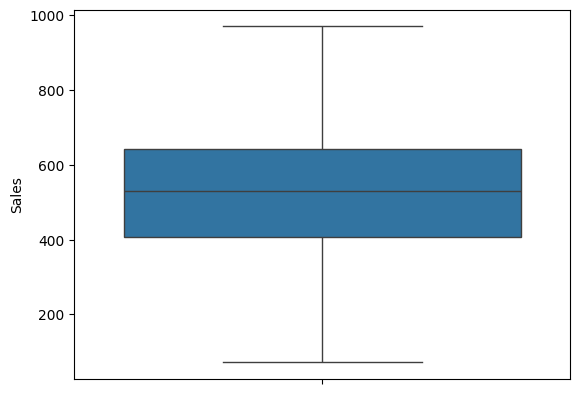

In [9]:
# Remove Outliers from Sales field

Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

# Find the bound

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Set the Bound

df = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]

sns.boxplot(df['Sales'])
plt.ylabel('Sales')
plt.show()

In [10]:
print('\nCovariance:- ',df.cov())

print('\nCorrelation:- ',df.corr())


Covariance:-               Temperature         Sales
Temperature    62.452819   1336.740617
Sales        1336.740617  29236.892495

Correlation:-               Temperature     Sales
Temperature     1.000000  0.989249
Sales           0.989249  1.000000


In [11]:
# Feature and Targer Variable

X = df[['Temperature']]
y = df['Sales']

print('\nX.shape :- ',X.shape)
print('\ny.shape :- ',y.shape)


X.shape :-  (493, 1)

y.shape :-  (493,)


In [12]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state = 42
)

print('\nX_train.shape :- ',X_train.shape)
print('\nX_test.shape :- ',X_test.shape)
print('\ny_train.shape :- ',y_train.shape)
print('\ny_test.shape :- ',y_test.shape)


X_train.shape :-  (394, 1)

X_test.shape :-  (99, 1)

y_train.shape :-  (394,)

y_test.shape :-  (99,)


In [13]:
# Model Selection & Training

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)

print('Model Trained Successfully!...')

Model Trained Successfully!...


In [14]:
# Predict the Testing Set

y_pred = model.predict(X_test)

print('X_test is Predicted!..')

X_test is Predicted!..


In [15]:
# Analyze The Model

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test,y_pred)

print('\nMean Absolute Error :- ',mae)
print('\nMean Squared Error :- ',mse)
print('\nRoot Mean Squared Error :- ',rmse)
print('\nR2 Score:- ',r2)


Mean Absolute Error :-  19.12401157186446

Mean Squared Error :-  594.1172017608767

Root Mean Squared Error :-  24.374519518564394

R2 Score:-  0.9761298391848678


In [16]:
# If Temperature is 40 then what is Sales?

prediction = model.predict([[40]])

print(f"\nIf Temperature is 40 then Ice_Cream'Sales is {prediction[0]}.")

# If Temperature is 12 then what is Sales?

prediction = model.predict([[12]])

print(f"\nIf Temperature is 12 then Ice_Cream'Sales is {prediction[0]}.")


If Temperature is 40 then Ice_Cream'Sales is 900.6287684377321.

If Temperature is 12 then Ice_Cream'Sales is 302.03523584727594.


C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


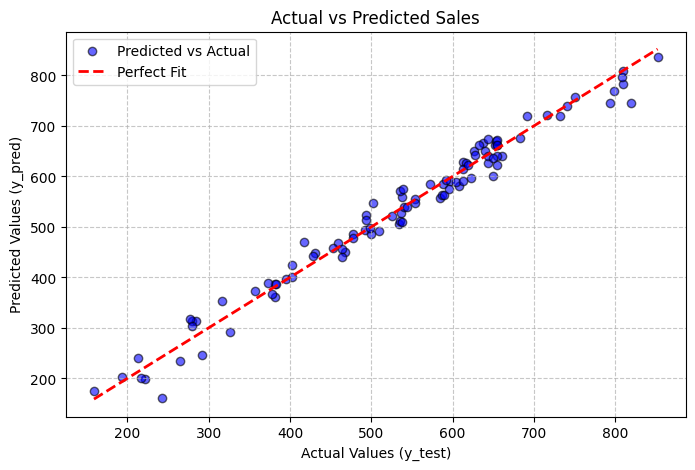

In [ ]:
# Compare the Actual vs Predicted Values

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='k', label='Predicted vs Actual')

# Ideal line (જ્યાં Actual = Predicted હોય)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()